<a href="https://colab.research.google.com/github/PranjalKabra/Fairness-Movie-Recommender/blob/main/Notebook_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import zipfile
import math
from sklearn.metrics import accuracy_score, r2_score

In [42]:
print(tf.__version__)

2.20.0


## Unzip the data

In [43]:
zip_path = '/content/dataset_movie.zip'
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
  if(zipfile.is_zipfile(zip_path)):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)
      ratings_file = os.path.join(extract_path, "u.data")
      user_attribute_file = os.path.join(extract_path, "u.user")


In [44]:
ratings_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(ratings_file, sep='\t', names=ratings_cols)
ratings = ratings.drop('unix_timestamp', axis=1)
# ratings

In [45]:
user_attributes_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv(user_attribute_file, sep='|', names=user_attributes_cols)
# users

The gender column is transformed into a binary format (0 for Male, 1 for Female), and unnecessary demographic columns (age, occupation, zip code) are dropped to focus strictly on gender fairness.

Dropping users with fewer than 10 ratings prevents the model from skewing its embeddings based on users with insufficient interaction history.

In [46]:
ratings['count'] = ratings.groupby('user_id')['movie_id'].transform('count')
ratings = ratings[ratings['count'] >= 10]
users['gender'] = users['gender'].map(lambda x: 1 if x == 'F' else 0)
users = users.drop(['age', 'occupation', 'zip_code'], axis=1)

len(ratings['user_id'].unique())

943

In [47]:
df = pd.merge(ratings, users, on='user_id', how='left')
df.head()
# len(df['user_id'].unique())

,user_id,movie_id,rating,count,gender
0,196,242,3,39,0
1,186,302,3,92,1
2,22,377,1,128,0
3,244,51,2,238,0
4,166,346,1,20,0


## Encoding Data for Embeddings

ID Encoding (Dictionaries): Creating user2user_encoded and movie2movie_encoded ensures that the maximum index passed to the Keras Embedding layer exactly matches the vocabulary size (number of unique users/movies), preventing out-of-bounds errors and saving memory.

In [48]:
user_ids = df["user_id"].unique().tolist()
movie_ids = df["movie_id"].unique().tolist()

user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)} # For decoding later
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)} # For decoding later

df["users"] = df["user_id"].map(user2user_encoded)
df["movies"] = df["movie_id"].map(movie2movie_encoded)

In [49]:
num_users = len(user_ids)
num_movies = len(movie_ids)
min_rating = min(df['rating'])
max_rating = max(df['rating'])

# df['rating'] = df['rating'].map(lambda x: (x - min_rating)).values

print(f'Number of users: {num_users}')
print(f'Number of movies: {num_movies}')
print(f'Min rating: {min_rating}')
print(f'Max rating: {max_rating}')
print(df.head())

Number of users: 943
Number of movies: 1682
Min rating: 1
Max rating: 5
   user_id  movie_id  rating  count  gender  users  movies
0      196       242       3     39       0      0       0
1      186       302       3     92       1      1       1
2       22       377       1    128       0      2       2
3      244        51       2    238       0      3       3
4      166       346       1     20       0      4       4


To help the neural network converge faster and output predictions in a standardized range, the target ratings (which originally range from 1 to 5) are normalized using Min-Max Scaling. This scales all ratings to a continuous range between 0 and 1.

**Min-Max Normalization Formula:**
$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
*Where $X$ is the original rating, $X_{min} = 1$, and $X_{max} = 5$.*

In [50]:
df = df.sample(frac=1, random_state=42)
df['rating'] = df['rating'].map(lambda x: (x - min_rating) / (max_rating - min_rating)).values
# xtract input
x = df[["users", "movies"]].values

# xtract targets
y_rating = df["rating"].values
y_gender = df["gender"].values


## Train & Test Split

Instead of just predicting a movie rating, the model is designed to perform Multi-Task Learning via an adversarial network structure.

The 7-Target Training Array (y_train): Because **the model outputs 7 different predictions/losses,** the target array must match. It includes:  
1. The actual normalized movie rating.  
2. Gender target for the Biased MLP (to train the predictor).  
3. Gender target for the Biased GMF (to train the predictor).  
4. Gender target for the Fair MLP (trained adversarially to confuse the discriminator).  
5. Gender target for the Fair GMF (trained adversarially to confuse the discriminator).  
6. An array of zeros to minimize the orthogonality (dot product) between Biased and Fair MLP vectors.  
7. An array of zeros to minimize the orthogonality between Biased and Fair GMF vectors.  



In [51]:
# splitting
train_indices = int(0.9 * df.shape[0])
x_train, x_val = x[:train_indices], x[train_indices:]

# build the massive 7-lists together answer key for Multi-Task Learning!

y_train = [
    y_rating[:train_indices],    # Target 1: Actual Rating
    y_gender[:train_indices],  # Target 2: Gender Biased mlp
    y_gender[:train_indices],  # Target 3: Gender Biased gmf
    y_gender[:train_indices],  # Target 4 :Fair mlp (Goal: Guess WRONG)
    y_gender[:train_indices],   # Target 5: Fair gmf (Goal: Guess WRONG)
    np.zeros(train_indices),    # Target 6: Zeros ub
    np.zeros(train_indices)    # Target 7: Zeros uf
]

y_val = [
    y_rating[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    np.zeros(df.shape[0]-train_indices),
    np.zeros(df.shape[0]-train_indices)
]

print('x_train shape : ', x_train.shape)
print('x_val shape   : ', x_val.shape)
print(y_train[0][0:10])

x_train shape :  (90000, 2)
x_val shape   :  (10000, 2)
[0.75 0.5  0.75 0.25 0.25 0.5  1.   0.75 0.5  0.75]


## **FairRec NeuCF model**

* NeuCF: Neural Collaborative Filtering - A framework combining matrix factorization and deep learning.  

* GMF: Generalized Matrix Factorization - A neural extension of traditional matrix factorization.  

* MLP: Multi-Layer Perceptron - A class of feedforward artificial neural network.  

* u_b: User Biased (Bias-Aware vector).  


* u_f: User Fair (Bias-Free vector).  


* m: Movie embedding vector.  

* L2 Regularization (l2(1e-6)): A penalty term added to the loss function to prevent overfitting by penalizing large weights.  


###  **Dual Architecture (GMF + MLP)**

Collaborative filtering is handled using two parallel networks.
* The GMF captures linear, low-rank interactions between users and movies, while
* the MLP utilizes hidden layers to capture non-linear, complex interactions.

### Formulation
**User Embedding Combination:**
$$u_{mlp} = u_{b\_mlp} + u_{f\_mlp}$$
$$u_{gmf} = u_{b\_gmf} + u_{f\_gmf}$$
*Where $u_b$ represents the bias-aware vector and $u_f$ represents the bias-free (fair) vector.*

**Generalized Matrix Factorization (GMF) Layer:**
$$\phi^{GMF} = u_{gmf} \odot m_{gmf}$$
*Where $\odot$ denotes the element-wise (Hadamard) product between the user and movie embeddings.*

**Multi-Layer Perceptron (MLP) Layer:**
$$\phi^{MLP} = W_L(a_{L-1}(...W_1(u_{mlp} \oplus m_{mlp})))$$
*Where $\oplus$ denotes concatenation, and $W$ represents the weights of the hidden dense layers.*

**Orthogonality Constraint:**
To ensure the fair embeddings do not contain any information from the biased embeddings, their dot product is forced towards zero:
$$Loss_{ortho} = \frac{u_b \cdot u_f}{||u_b|| ||u_f||} \approx 0$$

In [52]:
EMBEDDING_SIZE = 50

class RecommenderSys(keras.Model):
    def __init__(self, num_users, num_movies, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = EMBEDDING_SIZE

        # BIAS-AWARE USER VECTORS (u_b_mlp)
        self.user_embedding_biased_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-AWARE USER VECTORS (u_b_gmf)
        self.user_embedding_biased_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_f_mlp)
        self.user_embedding_fair_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_f_gmf)
        self.user_embedding_fair_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings mlp
        self.movie_embedding_mlp = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings gmf
        self.movie_embedding_gmf = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # mlp for combining user embeddings for mlp and movie embeddings for mlp
        self.mlp = keras.models.Sequential([
            layers.Dense(4*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(2*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(EMBEDDING_SIZE),
        ])

        # NN(no hidden layers) to combine mlp and gmf outputs
        self.neuCF = layers.Dense(1)

        # NNs(no hdden layers)  (To predict Gender)
        self.att_predictor_mlp = layers.Dense(1)
        self.att_predictor_gmf = layers.Dense(1)

        # NNs(no hdden layers)  (To discriminate Gender)
        self.att_discriminator_mlp = layers.Dense(1)
        self.att_discriminator_gmf = layers.Dense(1)

    def call(self, inputs):
        # get the user embeddings
        u_b_mlp = self.user_embedding_biased_mlp(inputs[:, 0])
        u_b_gmf = self.user_embedding_biased_gmf(inputs[:, 0])
        u_f_mlp = self.user_embedding_fair_mlp(inputs[:, 0])
        u_f_gmf = self.user_embedding_fair_gmf(inputs[:, 0])

        # get themovie embeddings
        m_mlp = self.movie_embedding_mlp(inputs[:, 1])
        m_gmf = self.movie_embedding_gmf(inputs[:, 1])

        # combining fair and biased user embeddings(u = ub + uf)
        u_mlp = tf.add(u_b_mlp, u_f_mlp)
        u_gmf = tf.add(u_b_gmf, u_f_gmf)

        # make the prediction layer for gmf and mlp
        gmf_layer = tf.multiply(u_gmf, m_gmf)
        mlp_layer = self.mlp(tf.concat([u_mlp, m_mlp], axis = 1))

        # final predicted rating
        predicted_rating = self.neuCF(tf.concat([gmf_layer, mlp_layer], 1))

        # gender predictor
        z_b_mlp = self.att_predictor_mlp(u_b_mlp) # z cap
        z_b_gmf = self.att_predictor_gmf(u_b_gmf)  # z tilda

        # gender discrimator
        z_f_gmf = self.att_discriminator_gmf(u_f_gmf)
        z_f_mlp = self.att_discriminator_mlp(u_f_mlp)

        # compute orthogonality loss which should be minimized btwn u_b and u_f
        ortho_loss_mlp = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_mlp, u_f_mlp])
        ortho_loss_gmf = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_gmf, u_f_gmf])

        # the sigmoid activation forces the rating to between 0 and 1
        return [
            predicted_rating,
            tf.nn.sigmoid(z_b_mlp),
            tf.nn.sigmoid(z_b_gmf),
            tf.nn.sigmoid(z_f_mlp),
            tf.nn.sigmoid(z_f_gmf),
            ortho_loss_mlp,
            ortho_loss_gmf
        ]

## Loss func

The User ID splits into two distinct paths: a Bias-Aware embedding (which explicitly predicts gender) and a Bias-Free embedding (which is penalized if it can predict gender).

An orthogonality constraint ensures these two representations do not share overlapping information, forcing the Bias-Free vector to rely solely on pure movie preferences.

**Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
*Where $y_i$ is the actual normalized rating and $\hat{y}_i$ is the predicted rating. This is the primary objective function for the recommender.*

**Binary Cross-Entropy (BCE):**
$$BCE = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$
*Used to train the Biased MLP/GMF to correctly classify gender (0 or 1).*

**Negative Binary Cross-Entropy (Adversarial Loss):**
$$Loss_{adv} = -1.0 \times BCE$$
*Used to train the Fair MLP/GMF. Minimizing this negative loss is mathematically equivalent to maximizing the standard BCE, forcing the network to guess gender poorly.*

**Mean Squared Error (MSE) for Orthogonality:**
$$MSE = \frac{1}{N} \sum_{i=1}^{N} ((u_b \cdot u_f) - 0)^2$$
*Used to force the dot product of the biased and fair embeddings to exactly 0 (since the target array is `np.zeros`).*

In [53]:
def neg_binary_crossentropy(y_true, y_pred):
    return -1.0 * keras.losses.binary_crossentropy(y_true, y_pred)

def root_mean_squared_error(y_true, y_pred):
    return keras.backend.sqrt(keras.backend.mean(keras.backend.square(y_pred - y_true)))

In [54]:
model = RecommenderSys(num_users, num_movies)
model.compile(
    loss=[root_mean_squared_error, tf.keras.losses.BinaryCrossentropy(), tf.keras.losses.BinaryCrossentropy(), neg_binary_crossentropy, neg_binary_crossentropy, tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanSquaredError()],
    loss_weights=[1,0.1,0.1,0.1,0.1,0.5,0.5],
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
)

## Train

In [55]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=7,
    verbose=1,
    validation_data=(x_val, y_val),
)

Epoch 1/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - binary_crossentropy_loss: 0.1528 - loss: -3.5045 - mean_squared_error_loss: 9.3869e-04 - neg_binary_crossentropy_loss: -25.3191 - root_mean_squared_error_loss: 0.2480 - val_binary_crossentropy_loss: 0.0092 - val_loss: -12.1393 - val_mean_squared_error_loss: 5.3670e-06 - val_neg_binary_crossentropy_loss: -75.3271 - val_root_mean_squared_error_loss: 0.2399
Epoch 2/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_crossentropy_loss: 0.0041 - loss: -29.0460 - mean_squared_error_loss: 1.1915e-05 - neg_binary_crossentropy_loss: -163.5850 - root_mean_squared_error_loss: 0.2350 - val_binary_crossentropy_loss: 0.0021 - val_loss: -49.2718 - val_mean_squared_error_loss: 1.8464e-05 - val_neg_binary_crossentropy_loss: -267.4233 - val_root_mean_squared_error_loss: 0.2389
Epoch 3/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - binary_crossentropy_loss: 0.0014 - loss: -75.2150 - mean_squared_error_loss: 1.2664e-04 - neg_binary_crossentropy_l

In [56]:
model.evaluate(x_val, y_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_crossentropy_loss: 1.3301e-04 - loss: -463.7917 - mean_squared_error_loss: 5.4709e-04 - neg_binary_crossentropy_loss: -2363.8838 - root_mean_squared_error_loss: 0.2352


[-463.79168701171875,
 0.2352365404367447,
 0.00013300873979460448,
 0.00013300873979460448,
 -2363.8837890625,
 -2363.8837890625,
 0.0005470938631333411,
 0.0005470938631333411]

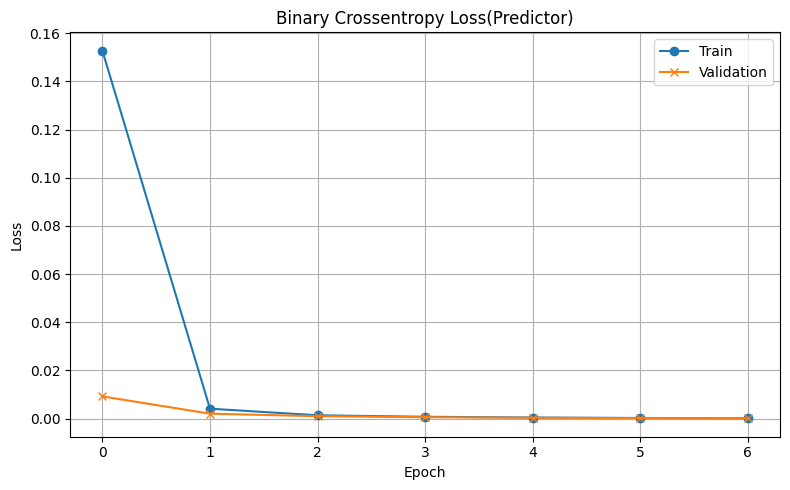

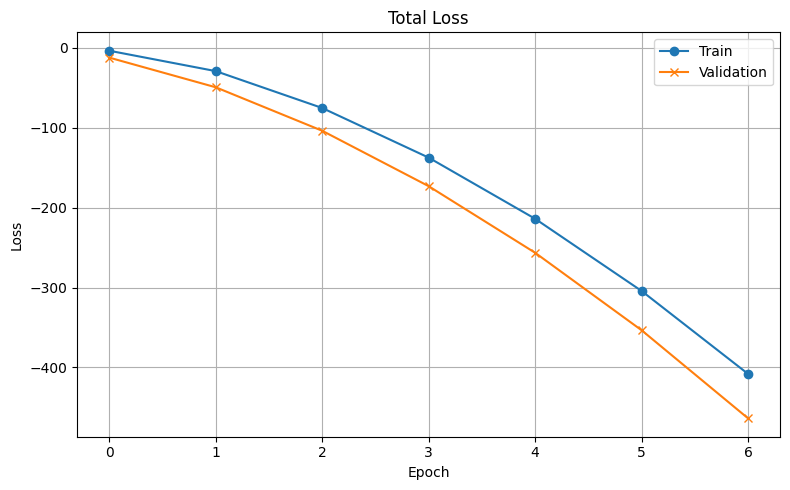

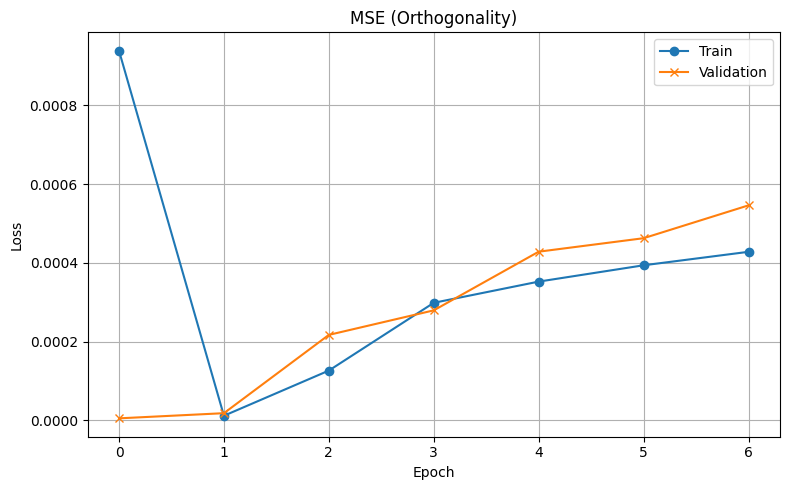

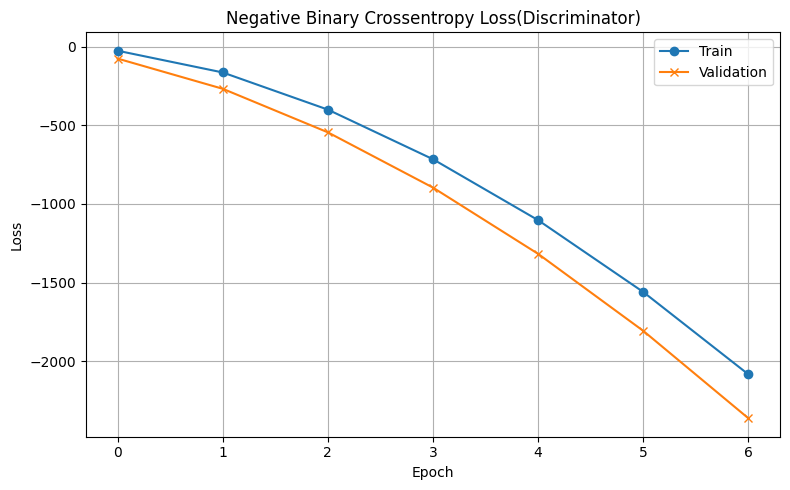

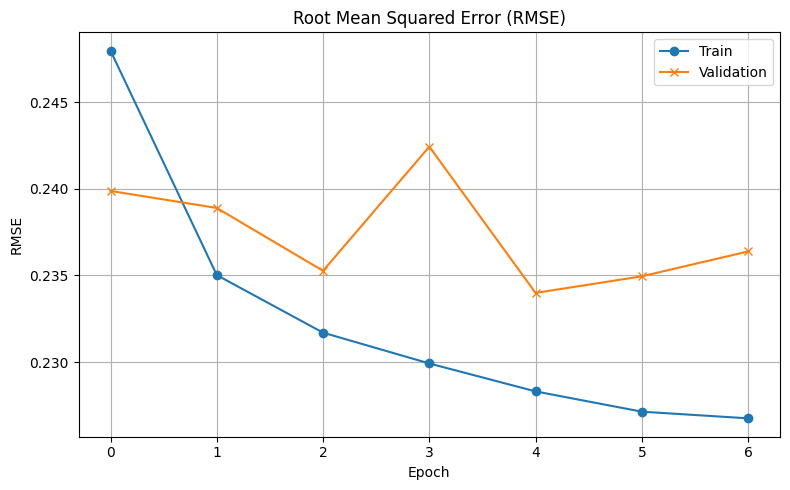

In [57]:
def plot_metrics(history, key, title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[key], marker='o', label='Train')
    plt.plot(history.history["val_" + key], marker='x', label='Validation')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the plot function for each metric
plot_metrics(history, "binary_crossentropy_loss", "Binary Crossentropy Loss(Predictor)", "Loss")
plot_metrics(history, "loss", "Total Loss", "Loss")
plot_metrics(history, "mean_squared_error_loss", "MSE (Orthogonality)", "Loss")
plot_metrics(history, "neg_binary_crossentropy_loss", "Negative Binary Crossentropy Loss(Discriminator)", "Loss")
plot_metrics(history, "root_mean_squared_error_loss", "Root Mean Squared Error (RMSE)", "RMSE")

# Unified User embeddings

the model forms a Unified User Embedding by combining the learned features of both the bias-aware (biased) and bias-free (fair) user vectors. The interaction between this unified user vector and the target movie vector dictates the predicted rating score.

The model aggregates the biased user vector ($\mathbf{u}_b$) and the fair user vector ($\mathbf{u}_f$) to create a comprehensive representation of the user's preferences.

In [58]:
# UNIFIED USER EMBEDDINGS

ub_mlp_w = np.array(model.user_embedding_biased_mlp.get_weights())
ub_gmf_w = np.array(model.user_embedding_biased_gmf.get_weights())
# print(np.shape(model.user_embedding_biased_mlp.get_weights()))
uf_mlp_w = np.array(model.user_embedding_fair_mlp.get_weights())
uf_gmf_w = np.array(model.user_embedding_fair_gmf.get_weights())

unified_user_embedding = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

output = unified_user_embedding(x_train[:,0])
# print(np.shape(unified_user_embedding.get_weights()))
w_mlp = np.add(ub_mlp_w, uf_mlp_w)
w_gmf = np.add(ub_gmf_w, uf_gmf_w)
w = np.add(w_mlp,w_gmf)
unified_user_embedding.set_weights(w)

# print(w.shape)

In [59]:
movie_df = pd.read_csv('/content/extracted_data/u.item', sep='|', header=None, encoding='latin-1')
movie_df = movie_df[[0, 1]]
movie_df.columns = ['movie_id', 'title']
movie_df.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [60]:
# TOP 10 FAIRNESS AWARE MOVIE RECOMMENDATIONS FOR A RANDOM USER USING BIAS-FREE EMBEDDINGS

user_id = df.user_id.sample(1).iloc[0] # Keep this in another cell else random user will change each time the cell runs
# user_id = 234
movies_watched_by_user = df[df.user_id == user_id]
movies_not_watched = movie_df[~movie_df['movie_id'].isin(movies_watched_by_user.movie_id.values)]['movie_id']
movies_not_watched = list(
    set(movies_not_watched).intersection(set(movie2movie_encoded.keys()))
)
movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]

user_encoder = user2user_encoded.get(user_id)
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched)
)

# print('len : ',len(user_movie_array))
uv = unified_user_embedding(user_movie_array[:,0])
mv = movies_embedding(user_movie_array[:,1])
ratings = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1]).numpy()
# print(ratings)

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices
]

print("Showing recommendations for user: {}".format(user_id))
print("====" * 9)
print("Movies with high ratings from user")
print("----" * 8)
top_movies_user = (
    movies_watched_by_user.sort_values(by="rating", ascending=False)
    .head(5)
    .movie_id.values
)
movie_df_rows = movie_df[movie_df["movie_id"].isin(top_movies_user)]
for row in movie_df_rows.itertuples():
    print(row.title)

print("----" * 8)
print("Top 10 movie recommendations")
print("----" * 8)
recommended_movies = movie_df[movie_df["movie_id"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(row.title)

Showing recommendations for user: 299
Movies with high ratings from user
--------------------------------
Much Ado About Nothing (1993)
Blade Runner (1982)
Henry V (1989)
Like Water For Chocolate (Como agua para chocolate) (1992)
Roman Holiday (1953)
--------------------------------
Top 10 movie recommendations
--------------------------------
Clerks (1994)
Reservoir Dogs (1992)
Mother (1996)
Pinocchio (1940)
Alice in Wonderland (1951)
Day the Earth Stood Still, The (1951)
Birds, The (1963)
Miller's Crossing (1990)
Cool Hand Luke (1967)
Night of the Living Dead (1968)


In [61]:
predictions = model.predict(x_val)
predicted_ratings = predictions[0]
predicted_ratings

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.23669979],
       [0.80406487],
       [0.39345658],
       ...,
       [0.6573944 ],
       [0.51503646],
       [0.7591013 ]], dtype=float32)

In [62]:
y_val[0]

array([0.5 , 0.75, 0.75, ..., 0.5 , 0.5 , 0.5 ])

In [63]:
from sklearn.metrics import r2_score
import numpy as np

# Print the true shape and a preview to verify
print("True Ratings: ", y_val[0][:5])
print("Predicted Ratings: ", np.reshape(predicted_ratings[:5], [-1]))

# Calculate R2 & RMSE
r2 = r2_score(y_val[0], predicted_ratings)
print('Actual Coefficient of Determination (R2): ', r2)

rmse = tf.keras.metrics.RootMeanSquaredError()
rmse.update_state(y_val[0],predicted_ratings)
print('RMSE : ',rmse.result().numpy())

True Ratings:  [0.5  0.75 0.75 0.75 0.25]
Predicted Ratings:  [0.23669979 0.80406487 0.39345658 0.8328281  0.63552123]
Actual Coefficient of Determination (R2):  0.30018760770536057
RMSE :  0.23737644


## Testing Fairness

In [64]:

discriminator = keras.Sequential([
    layers.Input(shape=(EMBEDDING_SIZE,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

gender_labels = []
for key in userencoded2user:
    gender_labels.append(df.loc[df["users"] == key, "gender"].values[0])
gender_labels = np.array(gender_labels).astype(int)

# len(gender_labels)
biased_embeddings = np.array(ub_mlp_w[0])
fair_embeddings = np.array(uf_mlp_w[0])
# print(fair_embeddings.shape, len(gender_labels))
history = discriminator.fit(biased_embeddings, gender_labels, epochs=10, batch_size=32)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.6000   
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.3871 
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.2070 
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.1037 
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0564 
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0345 
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0232 
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0167
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0127 
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0099 


WE want to minimize the score here.
if a user's movie tastes are perfectly stripped of gender, the Detective shouldn't be able to guess 0 (Male) or 1 (Female). It should be completely confused and guess a 50/50 coin toss (0.5).

x - 0.5: We look at every single guess (x) and subtract 0.5 to see how far away the Detective was from total confusion.

In [67]:
gender_predictions = discriminator.predict(fair_embeddings)
score = 0
for x in gender_predictions:
    score += abs(x-0.5)

score /= len(gender_predictions)
print(score)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[0.3381153]


In [68]:
yr = model.predict(x_val)[0]
yr.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(10000, 1)

In [69]:
from collections import defaultdict

e = Expectation (or Average)

g = Group (Female)

neg_g = Negative Group (Male)

y = Predicted Rating (from the neural network)

r = Real Rating (the true ground-truth stars)

j = Item/Movie ID

e_g_y_j_all: All Predicted ratings (y) for a movie (j) made by Females (g).

e_g_r_j_all: All Real ratings (r) for a movie (j) made by Females (g).

e_neg_g_y_j_all: All Predicted ratings (y) for a movie (j) made by Males (neg_g).

e_neg_g_r_j_all: All Real ratings (r) for a movie (j) made by Males (neg_g).

In [70]:
e_g_y_j_all = defaultdict(list)
e_neg_g_y_j_all = defaultdict(list)
e_g_r_j_all = defaultdict(list)
e_neg_g_r_j_all = defaultdict(list)

# print("---",np.count_nonzero(y_val[1]==1))
# print(x_val.shape)
for i in range(len(x_val)):
    if(y_val[1][i] == 1): #female
        e_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_g_r_j_all[x_val[i][1]].append(y_val[0][i])
    if(y_val[1][i] == 0): #male
        e_neg_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_neg_g_r_j_all[x_val[i][1]].append(y_val[0][i])

In [71]:
e_g_y_j = {}
e_neg_g_y_j = {}
e_g_r_j = {}
e_neg_g_r_j = {}
for k in e_g_y_j_all:
  e_g_y_j[k] = np.nanmean(e_g_y_j_all[k])
for k in e_g_r_j_all:
  e_g_r_j[k] = np.nanmean(e_g_r_j_all[k])
for k in e_neg_g_y_j_all:
  e_neg_g_y_j[k] = np.nanmean(e_neg_g_y_j_all[k])
for k in e_neg_g_r_j_all:
  e_neg_g_r_j[k] = np.nanmean(e_neg_g_r_j_all[k])
# print(e_g_y_j)

In [75]:
movies = set(x_val[:,1])
l = len(movies)
# print(l)

def safe_val(d, key):
    val = d.get(key, 0)
    return 0 if val is None or np.isnan(val) else val

val_score, abs_score, over_est, under_est = 0.0, 0.0, 0.0, 0.0

for movie in movies:
    eg_y = safe_val(e_g_y_j, movie)
    eg_r = safe_val(e_g_r_j, movie)
    eng_y = safe_val(e_neg_g_y_j, movie)
    eng_r = safe_val(e_neg_g_r_j, movie)

    val_score += np.abs((eg_y - eg_r) - (eng_y - eng_r))
    abs_score += np.abs(np.abs(eg_y - eg_r) - np.abs(eng_y - eng_r))
    over_est += np.abs(np.maximum(0, eg_y - eg_r) - np.maximum(0, eng_y - eng_r))
    under_est += np.abs(np.maximum(0, eg_r - eg_y) - np.maximum(0, eng_r - eng_y))

val_score /= l
abs_score /= l
over_est /= l
under_est /= l

#print(val_score, abs_score, over_est, under_est)
print("Baseline Metrics:")
print(f"Value Unfairness: {val_score:.4f}")
print(f"Absolute Unfairness: {abs_score:.4f}")
print(f"Overestimation Unfairness: {over_est:.4f}")
print(f"Underestimation Unfairness: {under_est:.4f}")

Baseline Metrics:
Value Unfairness: 0.1764
Absolute Unfairness: 0.1338
Overestimation Unfairness: 0.0912
Underestimation Unfairness: 0.0852


## Trying SVD for comparision

In [73]:
!pip install scikit-surprise

In [37]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.1)

baseline_model = SVD()
baseline_model.fit(trainset)

In [38]:
predictions = baseline_model.test(testset)

# Convert predictions to a DataFrame including true ratings
baseline_results_full = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est) for pred in predictions],
    columns=['user_id', 'item_id', 'true_rating', 'predicted_rating']
)

# Merge with the original df to attach demographic data (e.g., gender)
# 'movie_id' in df corresponds to 'item_id' in baseline_results_full
comparison_df = baseline_results_full.merge(df[['user_id', 'movie_id', 'gender']],
                                            left_on=['user_id', 'item_id'],
                                            right_on=['user_id', 'movie_id'],
                                            how='left')

# Drop the redundant 'movie_id' column if it was added during the merge
comparison_df = comparison_df.drop(columns=['movie_id'])

In [39]:
# Group the baseline predictions by demographic (e.g., gender)
group_g = comparison_df[comparison_df['gender'] == 1] # e.g., Male
group_neg_g = comparison_df[comparison_df['gender'] == 0] # e.g., Female

# Calculate the prediction errors (Expected vs Actual) for the baseline
e_g_y_j = group_g.groupby('item_id')['predicted_rating'].mean()
e_g_r_j = group_g.groupby('item_id')['true_rating'].mean()

e_neg_g_y_j = group_neg_g.groupby('item_id')['predicted_rating'].mean()
e_neg_g_r_j = group_neg_g.groupby('item_id')['true_rating'].mean()


In [40]:
def safe_val(d, key):
    val = d.get(key, 0)
    return 0 if val is None or np.isnan(val) else val

val_score, abs_score, over_est, under_est = 0.0, 0.0, 0.0, 0.0

for movie in movies:
    eg_y = safe_val(e_g_y_j, movie)
    eg_r = safe_val(e_g_r_j, movie)
    eng_y = safe_val(e_neg_g_y_j, movie)
    eng_r = safe_val(e_neg_g_r_j, movie)

    val_score += np.abs((eg_y - eg_r) - (eng_y - eng_r))
    abs_score += np.abs(np.abs(eg_y - eg_r) - np.abs(eng_y - eng_r))
    over_est += np.abs(np.maximum(0, eg_y - eg_r) - np.maximum(0, eng_y - eng_r))
    under_est += np.abs(np.maximum(0, eg_r - eg_y) - np.maximum(0, eng_r - eng_y))

val_score /= l
abs_score /= l
over_est /= l
under_est /= l

print("Baseline Metrics:")
print(f"Value Unfairness: {val_score:.4f}")
print(f"Absolute Unfairness: {abs_score:.4f}")
print(f"Overestimation Unfairness: {over_est:.4f}")
print(f"Underestimation Unfairness: {under_est:.4f}")

Baseline Metrics:
Value Unfairness: 0.2449
Absolute Unfairness: 0.2449
Overestimation Unfairness: 0.2449
Underestimation Unfairness: 0.0000
